[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Omer-Sella/strandDisplacement/blob/master/Ilaria2.ipynb)

In [ ]:

#@title { vertical-output: true}
from utils import *
from pathlib import Path
# 1. Provide a Path to png file with a PLTE field
png_path = 'imperialBlue_with_plte_2_colours.png'
# Optional - just for understanding PLTE, display the PLTE data. Also useful to check that we don't have too many colours
extract_plte_table(png_path)


# 2. Set the limit on the number of bits per chunk. This will affect how many bases are in every DNA strand.
K_BITS = 64  # Placeholder constant; you can change this later.

dna_chunks = png_to_dna_chunks(png_path, K_BITS)
print(f'Total output chunks: {len(dna_chunks)}')
#print('First 5 chunks:')
#for item in dna_chunks[:5]:
#    print({k: item[k] for k in ['png_chunk_type', 'field', 'subchunk_index', 'bits', 'dna']})


# Print the chunks that are relevant to PLTE, these are the chunks we want to change in the DNA sample
for c in dna_chunks:
    if c["png_chunk_type"] == "PLTE":
        print(c)

# 3. Reconstruct the png from the DNA chunks:
reconstructed_path = reconstruct_and_display_png(dna_chunks, 'reconstructed.png')


Edited PLTE chunks:
{'chunk_index': 1, 'png_chunk_type': 'PLTE', 'field': 'header', 'subchunk_index': 0, 'bits': '0000000000000000000000000000011001010000010011000101010001000101', 'valid_bits': 64, 'dna': 'CGAAGCGCGAACAGAGGATAGCAATCGAATGC', 'seed': 1}
{'chunk_index': 1, 'png_chunk_type': 'PLTE', 'field': 'palette', 'subchunk_index': 0, 'bits': '0000000000000000000000001001000011111111111111110000000000000000', 'valid_bits': 48, 'dna': 'CGAAGCGCGAACGTCAAGATAGATGATACTTA', 'seed': 1}
{'chunk_index': 1, 'png_chunk_type': 'PLTE', 'field': 'checksum', 'subchunk_index': 0, 'bits': '1110011001010010000100111100000000000000000000000000000000000000', 'valid_bits': 32, 'dna': 'GACGTAGTGCAGTGCATCTATCTAGATACTTA', 'seed': 1}
Reconstructed PNG written to: C:\Users\Omer\strandDisplacementPNG\imperialBlue_recolored.png


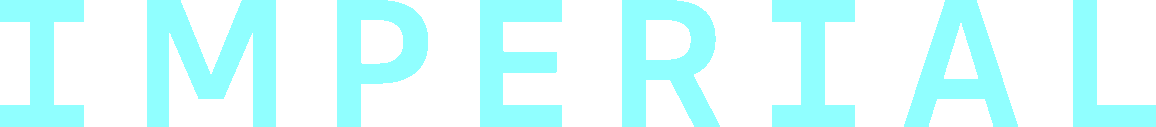

WindowsPath('imperialBlue_recolored.png')

In [5]:
edited_chunks = update_plte_entry_in_dna_chunks(dna_chunks, palette_index=1, new_rgb=(144, 255, 255))
print("Edited PLTE chunks:")
for c in edited_chunks:
    if c["png_chunk_type"] == "PLTE":
        print(c)
reconstruct_and_display_png(edited_chunks, "imperialBlue_recolored.png")

In [ ]:
# 4) Simulate sequencing with Badread, then check which DNA chunks are observed in reads.
import shutil
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from Bio import Align
from Bio.Seq import Seq as seq

# Build the DNA library from current chunks.
dna_library = [c['dna'] for c in dna_chunks]
if len(dna_library) == 0:
    raise ValueError('dna_chunks is empty. Run the encoding cell first.')

# Write FASTA for Badread input.
reference_fasta = Path('dna_chunks_reference.fasta')
with reference_fasta.open('w') as f:
    for i, d in enumerate(dna_library):
        f.write(f'>chunk_{i}\n{d}\n')

# Run Badread (expects badread installed and available on PATH).
if shutil.which('badread') is None:
    raise FileNotFoundError(
        "Badread executable not found. Install it first (e.g. pip install git+https://github.com/rrwick/Badread.git)."
    )

reads_fastq = Path('reads.fastq')
cmd = [
    'badread', 'simulate',
    '--reference', str(reference_fasta),
    '--quantity', '50x',
    '--error_model', 'nanopore2020',
    '--qscore_model', 'nanopore2020',
    '--identity', '90,98,5',
]
with reads_fastq.open('w') as out_f:
    subprocess.run(cmd, stdout=out_f, stderr=subprocess.PIPE, text=True, check=True)

# Read FASTQ sequences.
def fastq_iterator(file_name: str):
    with open(file_name, 'r') as f:
        while True:
            identifier = f.readline()
            sequence = f.readline().strip()
            plus = f.readline()
            quality = f.readline()
            if not identifier:
                break
            if not sequence:
                continue
            yield sequence

reads = list(fastq_iterator(str(reads_fastq)))
if len(reads) == 0:
    raise ValueError('No reads found in reads.fastq')

# Similarity analysis: for each expected chunk, find best match in sequencing reads.
aligner = Align.PairwiseAligner()
aligner.mode = 'local'
aligner.match_score = 1
aligner.mismatch_score = -1
aligner.open_gap_score = -1
aligner.extend_gap_score = -1

records = []
for idx, d in enumerate(dna_library):
    d_seq = seq(d)
    d_rc = d_seq.reverse_complement()

    best_score = float('-inf')
    best_read = ''
    for r in reads:
        r_seq = seq(r)
        score_fwd = aligner.score(r_seq, d_seq)
        score_rev = aligner.score(r_seq, d_rc)
        score = max(score_fwd, score_rev)
        if score > best_score:
            best_score = score
            best_read = r

    # Conservative detection threshold; tune as needed.
    threshold = 0.8 * len(d)
    records.append({
        'chunk_idx': idx,
        'dna_len': len(d),
        'best_score': best_score,
        'score_ratio': best_score / max(1, len(d)),
        'threshold': threshold,
        'present': best_score >= threshold,
        'best_read_len': len(best_read),
    })

matches_df = pd.DataFrame(records)
display(matches_df.head(10))
print(f"Detected chunks: {matches_df['present'].sum()} / {len(matches_df)}")

# Graph 1: presence/absence per chunk index.
fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(matches_df['chunk_idx'], matches_df['present'].astype(int))
ax.set_title('Chunk Presence in Badread Results (1=present, 0=absent)')
ax.set_xlabel('Chunk index')
ax.set_ylabel('Presence')
ax.set_ylim(-0.05, 1.05)
plt.show()

# Graph 2: best alignment score ratio per chunk.
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(matches_df['chunk_idx'], matches_df['score_ratio'], marker='o', linewidth=1)
ax.axhline(y=0.8, color='r', linestyle='--', label='Presence threshold ratio (0.8)')
ax.set_title('Best Alignment Score Ratio per Chunk')
ax.set_xlabel('Chunk index')
ax.set_ylabel('best_score / chunk_length')
ax.legend()
plt.show()

# Graph 3: how many chunks were found.
presence_counts = matches_df['present'].value_counts().rename(index={True: 'present', False: 'absent'})
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(presence_counts.index.astype(str), presence_counts.values)
ax.set_title('Summary: Present vs Absent Chunks')
ax.set_ylabel('Count')
plt.show()